# Red Neuronal Profunda — Modelo Sustituto de la Ecuación de Difusión

**Objetivo:** Entrenar una red neuronal profunda (DNN) que aprenda la relación funcional

$$\mathcal{N}:\; (x,\, t) \;\longrightarrow\; T(x,t)$$

a partir de los datos numéricos generados por el método de **Crank-Nicolson** (`CNPY.dat`).

---

### Estrategia
| Etapa | Descripción |
|---|---|
| **Datos** | Expansión de `CNPY.dat` → pares `(t, x) → T` |
| **Arquitecturas** | 3 DNNs con distinto número de capas y neuronas |
| **Entrenamiento** | MSE + Adam, EarlyStopping, split 70/15/15 |
| **Evaluación** | MSE, MAE, R², curvas de pérdida, mapas de error |
| **Comparación** | Tabla resumen + gráfica de eficiencia |

---

### Las tres arquitecturas
| Modelo | Capas ocultas | Neuronas/capa | Parámetros aprox. |
|---|---|---|---|
| **Arch A** — Shallow | 2 | 32 | ~1 200 |
| **Arch B** — Medium | 4 | 64 | ~12 500 |
| **Arch C** — Deep | 6 | 128 | ~83 000 |

## Celda 1 — Importaciones y configuración global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Semilla global para reproducibilidad ─────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Parametros fisicos del problema ──────────────────────────
alpha = 0.2
L     = 1.0
N     = 10
dx    = L / N

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU disponible     : {len(tf.config.list_physical_devices('GPU')) > 0}")

I0000 00:00:1773892304.894847   33584 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.21.0
Keras version      : 3.13.2
GPU disponible     : True


## Celda 2 — Carga y preparación del dataset

Se expande `CNPY.dat` para obtener pares `(t, x) → T`.
Cada fila del `.dat` tiene 601 instantes de tiempo y 11 nodos espaciales,
generando **6 611 muestras** totales.

In [3]:
# ── Cargar CNPY.dat ───────────────────────────────────────────
dat = np.loadtxt('CNPY.dat', skiprows=1)
# columnas: t | T1(x=0) | T2(x=0.1) | ... | T10(x=0.9) | T_frontera(x=1.0)

t_col   = dat[:, 0]           # 601 valores de tiempo
T_mat   = dat[:, 1:12]        # 601 x 11  (nodos x=0..1)

x_grid  = np.linspace(0, L, N+1)   # [0, 0.1, ..., 1.0]

# ── Expandir a pares (t, x) -> T ─────────────────────────────
# Para cada instante t_k y cada nodo x_i se crea una muestra
t_list, x_list, T_list = [], [], []
for k, t in enumerate(t_col):
    for i, xi in enumerate(x_grid):
        t_list.append(t)
        x_list.append(xi)
        T_list.append(T_mat[k, i])

t_arr = np.array(t_list, dtype=np.float32)
x_arr = np.array(x_list, dtype=np.float32)
T_arr = np.array(T_list, dtype=np.float32)

# ── Features e inputs ────────────────────────────────────────
X_raw = np.column_stack([t_arr, x_arr])   # shape (6611, 2)
y_raw = T_arr.reshape(-1, 1)              # shape (6611, 1)

print(f"Dataset expandido  : {X_raw.shape[0]} muestras")
print(f"Entradas           : t en [{t_arr.min():.2f}, {t_arr.max():.2f}],  "
      f"x en [{x_arr.min():.2f}, {x_arr.max():.2f}]")
print(f"Salida             : T en [{T_arr.min():.4f}, {T_arr.max():.4f}] gC")

# ── Normalización MinMax a [0, 1] ────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw).astype(np.float32)
y_scaled = scaler_y.fit_transform(y_raw).astype(np.float32)

# ── Split 70 / 15 / 15 ───────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_scaled, y_scaled, test_size=0.30, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp,    y_tmp,    test_size=0.50, random_state=SEED)

print(f"\nSplit:")
print(f"  Entrenamiento : {X_tr.shape[0]:5d} muestras  (70 %)")
print(f"  Validacion    : {X_val.shape[0]:5d} muestras  (15 %)")
print(f"  Test          : {X_te.shape[0]:5d} muestras  (15 %)")

Dataset expandido  : 6611 muestras
Entradas           : t en [0.00, 30.00],  x en [0.00, 1.00]
Salida             : T en [0.0000, 100.0012] gC

Split:
  Entrenamiento :  4627 muestras  (70 %)
  Validacion    :   992 muestras  (15 %)
  Test          :   992 muestras  (15 %)


## Celda 3 — Definición de las tres arquitecturas

| Modelo | Capas ocultas | Neuronas | Activación | Regularización |
|---|---|---|---|---|
| **Arch A** | 2 | 32 | ReLU | Dropout 0.1 |
| **Arch B** | 4 | 64 | ReLU | Dropout 0.1 + L2 |
| **Arch C** | 6 | 128 | ReLU | Dropout 0.2 + L2 |

In [4]:
def build_arch_A():
    """
    Arch A — Shallow (2 capas ocultas, 32 neuronas)
    La red mas simple. Buena linea base para comparar.
    Pocas capas -> menor capacidad de representacion.
    """
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        # ── Capa oculta 1 ──────────────────────────
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        # ── Capa oculta 2 ──────────────────────────
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        # ── Salida ─────────────────────────────────
        layers.Dense(1, activation='linear')
    ], name='Arch_A_Shallow')
    return model


def build_arch_B():
    """
    Arch B — Medium (4 capas ocultas, 64 neuronas)
    Capacidad intermedia. Regularizacion L2 para controlar
    sobreajuste al aumentar el numero de parametros.
    """
    l2 = regularizers.l2(1e-4)
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        # ── Capas ocultas 1-4 ──────────────────────
        layers.Dense(64, activation='relu', kernel_regularizer=l2),
        layers.Dropout(0.1),
        layers.Dense(64, activation='relu', kernel_regularizer=l2),
        layers.Dropout(0.1),
        layers.Dense(64, activation='relu', kernel_regularizer=l2),
        layers.Dropout(0.1),
        layers.Dense(64, activation='relu', kernel_regularizer=l2),
        layers.Dropout(0.1),
        # ── Salida ─────────────────────────────────
        layers.Dense(1, activation='linear')
    ], name='Arch_B_Medium')
    return model


def build_arch_C():
    """
    Arch C — Deep (6 capas ocultas, 128 neuronas)
    La red mas expresiva. Incluye BatchNormalization para
    estabilizar el entrenamiento en redes profundas y
    mayor Dropout para evitar sobreajuste.
    """
    l2 = regularizers.l2(1e-4)
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        # ── Capas ocultas 1-6 ──────────────────────
        layers.Dense(128, activation='relu', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(128, activation='relu', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(128, activation='relu', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64,  activation='relu', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64,  activation='relu', kernel_regularizer=l2),
        layers.Dropout(0.2),
        layers.Dense(32,  activation='relu', kernel_regularizer=l2),
        layers.Dropout(0.1),
        # ── Salida ─────────────────────────────────
        layers.Dense(1, activation='linear')
    ], name='Arch_C_Deep')
    return model


# ── Construir y mostrar resúmenes ─────────────────────────────
model_A = build_arch_A()
model_B = build_arch_B()
model_C = build_arch_C()

for name, m in [('Arch A — Shallow', model_A),
                ('Arch B — Medium',  model_B),
                ('Arch C — Deep',    model_C)]:
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    m.summary()
    print(f"  Parametros entrenables: {m.count_params():,}")

I0000 00:00:1773892389.938914   33584 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12951 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:07:00.0, compute capability: 8.9



  Arch A — Shallow


Model: "Arch_A_Shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,729 (194.25 KB)

 Trainable params: 48,833 (190.75 KB)

 Non-trainable params: 896 (3.50 KB)

  Parametros entrenables: 49,729


## Celda 4 — Compilación y entrenamiento de las tres arquitecturas

- **Optimizador:** Adam con `learning_rate = 1e-3`
- **Función de pérdida:** MSE (error cuadrático medio)
- **EarlyStopping:** paciencia 30 épocas sobre `val_loss`
- **ReduceLROnPlateau:** reduce LR × 0.5 si no mejora en 15 épocas
- **Épocas máximas:** 500

In [5]:
EPOCHS   = 500
BATCH    = 128
LR       = 1e-3

def get_callbacks(nombre):
    """Callbacks comunes para los tres modelos."""
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=30,
            restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=15, min_lr=1e-6, verbose=1),
    ]

historiales = {}
tiempos_train = {}

for nombre, modelo in [('Arch_A', model_A),
                        ('Arch_B', model_B),
                        ('Arch_C', model_C)]:
    print(f"\n{'#'*55}")
    print(f"  Entrenando {nombre}...")
    print(f"{'#'*55}")

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='mse',
        metrics=['mae']
    )

    t0 = time.perf_counter()
    hist = modelo.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=get_callbacks(nombre),
        verbose=0
    )
    t1 = time.perf_counter()

    historiales[nombre]    = hist
    tiempos_train[nombre]  = t1 - t0

    epocas_reales = len(hist.history['loss'])
    val_loss_min  = min(hist.history['val_loss'])
    print(f"  Epocas ejecutadas : {epocas_reales}")
    print(f"  Mejor val_loss    : {val_loss_min:.6f}")
    print(f"  Tiempo            : {t1-t0:.2f} s")


#######################################################
  Entrenando Arch_A...
#######################################################


I0000 00:00:1773892393.996786   33846 service.cc:153] XLA service 0x765ab80302f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773892393.996800   33846 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773892394.037005   33846 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773892394.168866   33846 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1773892394.209469   33846 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1812__.11
I0000 00:00:1773892394.649711   33846 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 51: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 70: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 85: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 100: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 115: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 130: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 130: early stopping
Restoring model weights from the end of the best epoch: 100.
  Epocas ejecutadas : 130
  Mejor val_loss    : 0.000384
  Tiempo            : 17.92 s

#######################################################
  Entrenando Arch_B...
#######################################################


I0000 00:00:1773892412.442138   33847 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32288__.20
I0000 00:00:1773892412.510770   33847 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1773892412.838839   43425 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_8', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1773892412.852477   33847 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1773892413.168744   43432 subprocess_compilation.cc:348] ptxas warning : Registers are spill


Epoch 100: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 118: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 133: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 151: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 166: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 181: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 195: early stopping
Restoring model weights from the end of the best epoch: 165.
  Epocas ejecutadas : 195
  Mejor val_loss    : 0.001222
  Tiempo            : 28.21 s

#######################################################
  Entrenando Arch_C...
#######################################################


I0000 00:00:1773892441.866628   33844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_80273__.50
I0000 00:00:1773892441.987349   33844 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1773892442.325483   57690 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1773892442.334331   33844 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1773892442.764406   33844 dot_search_space.cc:240] All configs were filtered out because none


Epoch 175: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 220: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 251: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 273: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 288: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 315: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 330: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 345: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 360: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.

Epoch 375: ReduceLROnPlateau reducing learning rate to 1e-06.
Epoch 388: early stopping
Restoring model weights from the end of the best epoch: 358.
  Epocas ejecutadas : 388
  Mejor val_loss    : 0.000510
  Tiempo            : 61.50 s


## Celda 5 — Evaluación en el conjunto de test

Las predicciones se desnormalizan antes de calcular las métricas
para que MSE y MAE estén en unidades reales de temperatura (°C).

In [6]:
resultados = {}

for nombre, modelo in [('Arch_A', model_A),
                        ('Arch_B', model_B),
                        ('Arch_C', model_C)]:

    # -- Prediccion en test (escala normalizada)
    y_pred_scaled = modelo.predict(X_te, verbose=0)

    # -- Desnormalizar a grados Celsius reales
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_true_real = scaler_y.inverse_transform(y_te).flatten()

    # -- Metricas en escala real
    mse  = mean_squared_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true_real, y_pred_real)
    r2   = r2_score(y_true_real, y_pred_real)
    max_err = np.max(np.abs(y_true_real - y_pred_real))

    resultados[nombre] = {
        'MSE'         : mse,
        'RMSE'        : rmse,
        'MAE'         : mae,
        'R2'          : r2,
        'Max_Error'   : max_err,
        'Tiempo_train': tiempos_train[nombre],
        'Epocas'      : len(historiales[nombre].history['loss']),
        'Params'      : [model_A, model_B, model_C]
                         [['Arch_A','Arch_B','Arch_C'].index(nombre)].count_params(),
        'y_pred'      : y_pred_real,
        'y_true'      : y_true_real,
    }

# -- Tabla resumen
df_res = pd.DataFrame({
    'Modelo'     : list(resultados.keys()),
    'Parametros' : [resultados[k]['Params']        for k in resultados],
    'Epocas'     : [resultados[k]['Epocas']        for k in resultados],
    'MSE [gC2]'  : [round(resultados[k]['MSE'],  4) for k in resultados],
    'RMSE [gC]'  : [round(resultados[k]['RMSE'], 4) for k in resultados],
    'MAE [gC]'   : [round(resultados[k]['MAE'],  4) for k in resultados],
    'R2'         : [round(resultados[k]['R2'],   5) for k in resultados],
    'MaxErr [gC]': [round(resultados[k]['Max_Error'],3) for k in resultados],
    'T_train [s]': [round(resultados[k]['Tiempo_train'],2) for k in resultados],
})

print("\n" + "="*75)
print("  TABLA COMPARATIVA — METRICAS EN CONJUNTO DE TEST")
print("="*75)
display(df_res)

mejor = df_res.loc[df_res['MAE [gC]'].idxmin(), 'Modelo']
print(f"\n  Mejor modelo por MAE: {mejor}")

I0000 00:00:1773892509.825291   33845 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1773892510.241890   86145 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 164 bytes spill stores, 164 bytes spill loads

I0000 00:00:1773892510.653524   33846 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1773892510.998304   86225 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1773892511.1


  TABLA COMPARATIVA — METRICAS EN CONJUNTO DE TEST


,Modelo,Parametros,Epocas,MSE [gC2],RMSE [gC],MAE [gC],R2,MaxErr [gC],T_train [s]
0,Arch_A,1185,130,4.9705,2.2295,1.5159,0.99306,34.530998,17.92
1,Arch_B,12737,195,3.0710,1.7524,0.8079,0.99571,34.134998,28.21
2,Arch_C,49729,388,0.7136,0.8447,0.4944,0.99900,5.721000,61.50



  Mejor modelo por MAE: Arch_C


## Celda 6 — Gráfica 1: Curvas de pérdida (entrenamiento y validación)

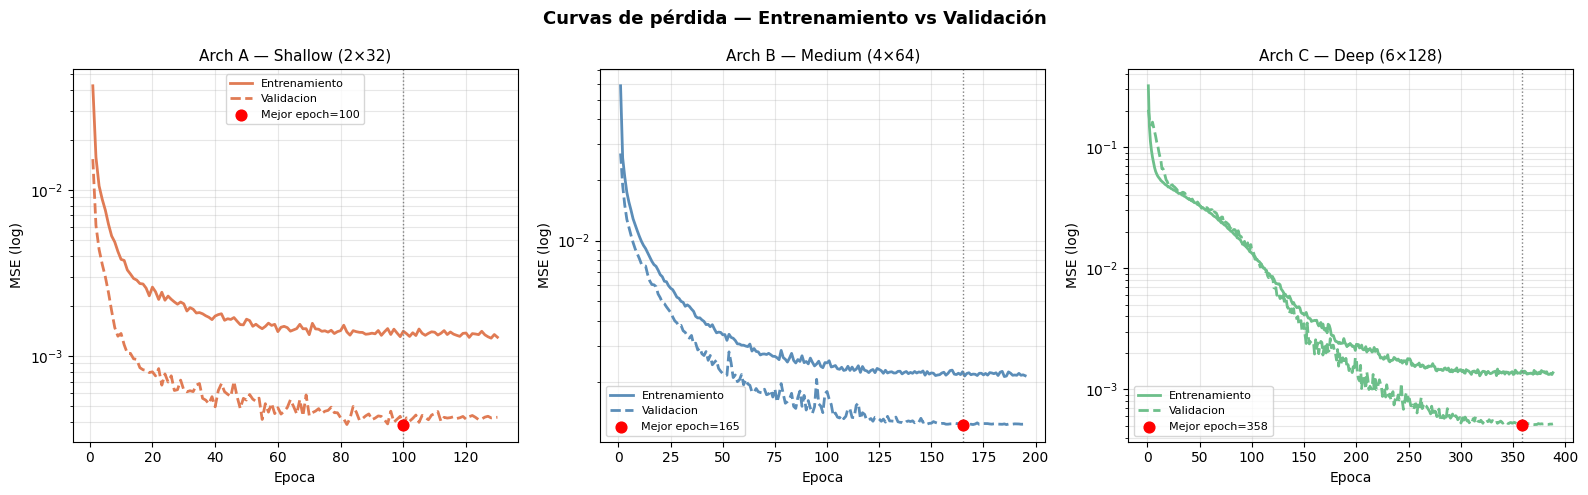

In [7]:
colores  = {'Arch_A': '#E07B54', 'Arch_B': '#5B8DB8', 'Arch_C': '#6DBF8A'}
etiquetas = {'Arch_A': 'Arch A — Shallow (2×32)',
             'Arch_B': 'Arch B — Medium (4×64)',
             'Arch_C': 'Arch C — Deep (6×128)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, hist) in zip(axes, historiales.items()):
    ep  = range(1, len(hist.history['loss']) + 1)
    col = colores[nombre]

    ax.semilogy(ep, hist.history['loss'],     color=col,
                lw=2,   label='Entrenamiento')
    ax.semilogy(ep, hist.history['val_loss'], color=col,
                lw=2, ls='--', label='Validacion')

    # Marcar el mejor epoch
    best_ep  = np.argmin(hist.history['val_loss']) + 1
    best_val = min(hist.history['val_loss'])
    ax.axvline(best_ep, color='gray', lw=1, ls=':')
    ax.scatter([best_ep], [best_val], color='red', zorder=5, s=60,
               label=f'Mejor epoch={best_ep}')

    ax.set_title(etiquetas[nombre], fontsize=11)
    ax.set_xlabel('Epoca', fontsize=10)
    ax.set_ylabel('MSE (log)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle('Curvas de pérdida — Entrenamiento vs Validación',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('perdida_arquitecturas.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 7 — Gráfica 2: Predicción vs Valor real (scatter test)

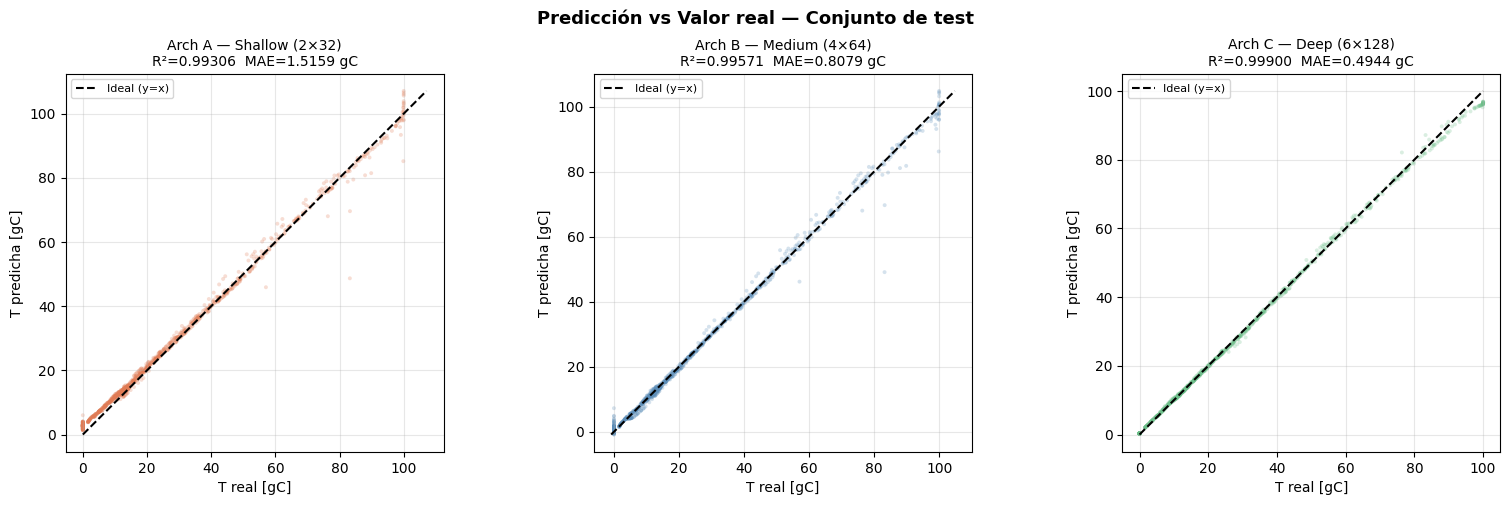

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, nombre in zip(axes, resultados):
    y_true = resultados[nombre]['y_true']
    y_pred = resultados[nombre]['y_pred']
    r2     = resultados[nombre]['R2']
    mae    = resultados[nombre]['MAE']
    col    = colores[nombre]

    ax.scatter(y_true, y_pred, alpha=0.25, s=8,
               color=col, edgecolors='none')

    # Linea ideal y=x
    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Ideal (y=x)')

    ax.set_xlabel('T real [gC]',  fontsize=10)
    ax.set_ylabel('T predicha [gC]', fontsize=10)
    ax.set_title(f"{etiquetas[nombre]}\nR²={r2:.5f}  MAE={mae:.4f} gC",
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', 'box')

fig.suptitle('Predicción vs Valor real — Conjunto de test',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 8 — Gráfica 3: Distribución del error absoluto (histograma)

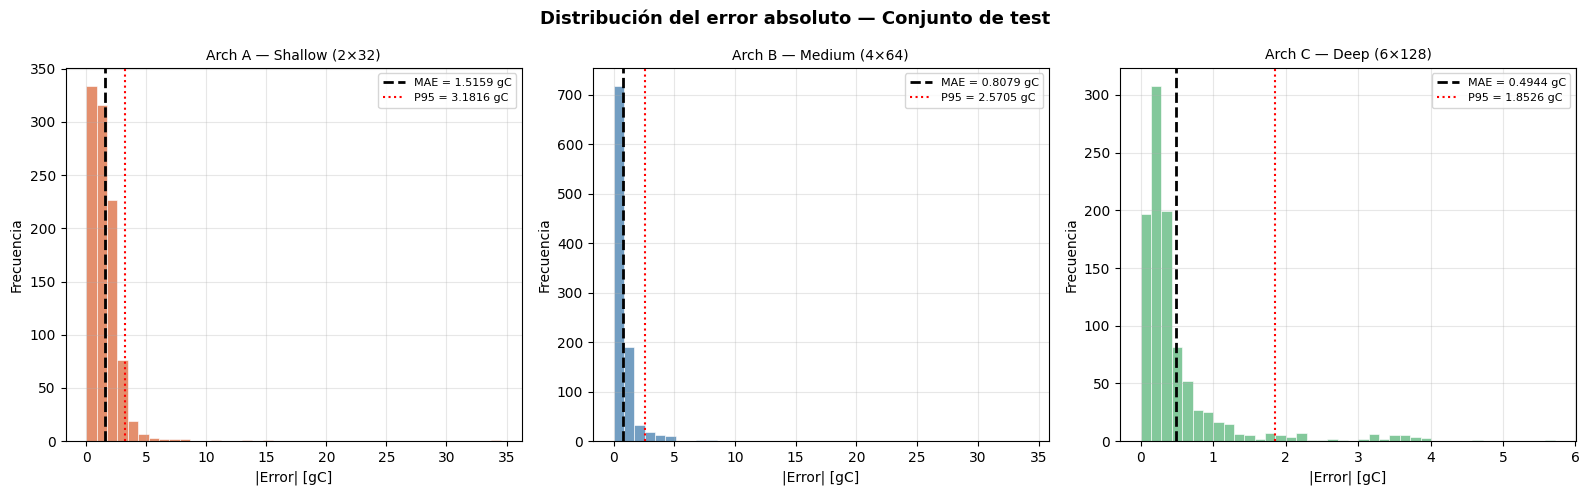

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, nombre in zip(axes, resultados):
    y_true  = resultados[nombre]['y_true']
    y_pred  = resultados[nombre]['y_pred']
    err_abs = np.abs(y_true - y_pred)
    col     = colores[nombre]

    ax.hist(err_abs, bins=40, color=col, alpha=0.85,
            edgecolor='white', linewidth=0.5)

    ax.axvline(err_abs.mean(), color='black', lw=2,
               ls='--', label=f'MAE = {err_abs.mean():.4f} gC')
    ax.axvline(np.percentile(err_abs, 95), color='red', lw=1.5,
               ls=':', label=f'P95 = {np.percentile(err_abs,95):.4f} gC')

    ax.set_xlabel('|Error| [gC]', fontsize=10)
    ax.set_ylabel('Frecuencia',   fontsize=10)
    ax.set_title(etiquetas[nombre], fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Distribución del error absoluto — Conjunto de test',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histograma_error.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 9 — Gráfica 4: Superficie predicha vs numérica en todo el dominio

Se evalúan los tres modelos sobre una malla densa `(t, x)` y se
comparan las superficies $T(x,t)$ con la solución numérica de referencia.

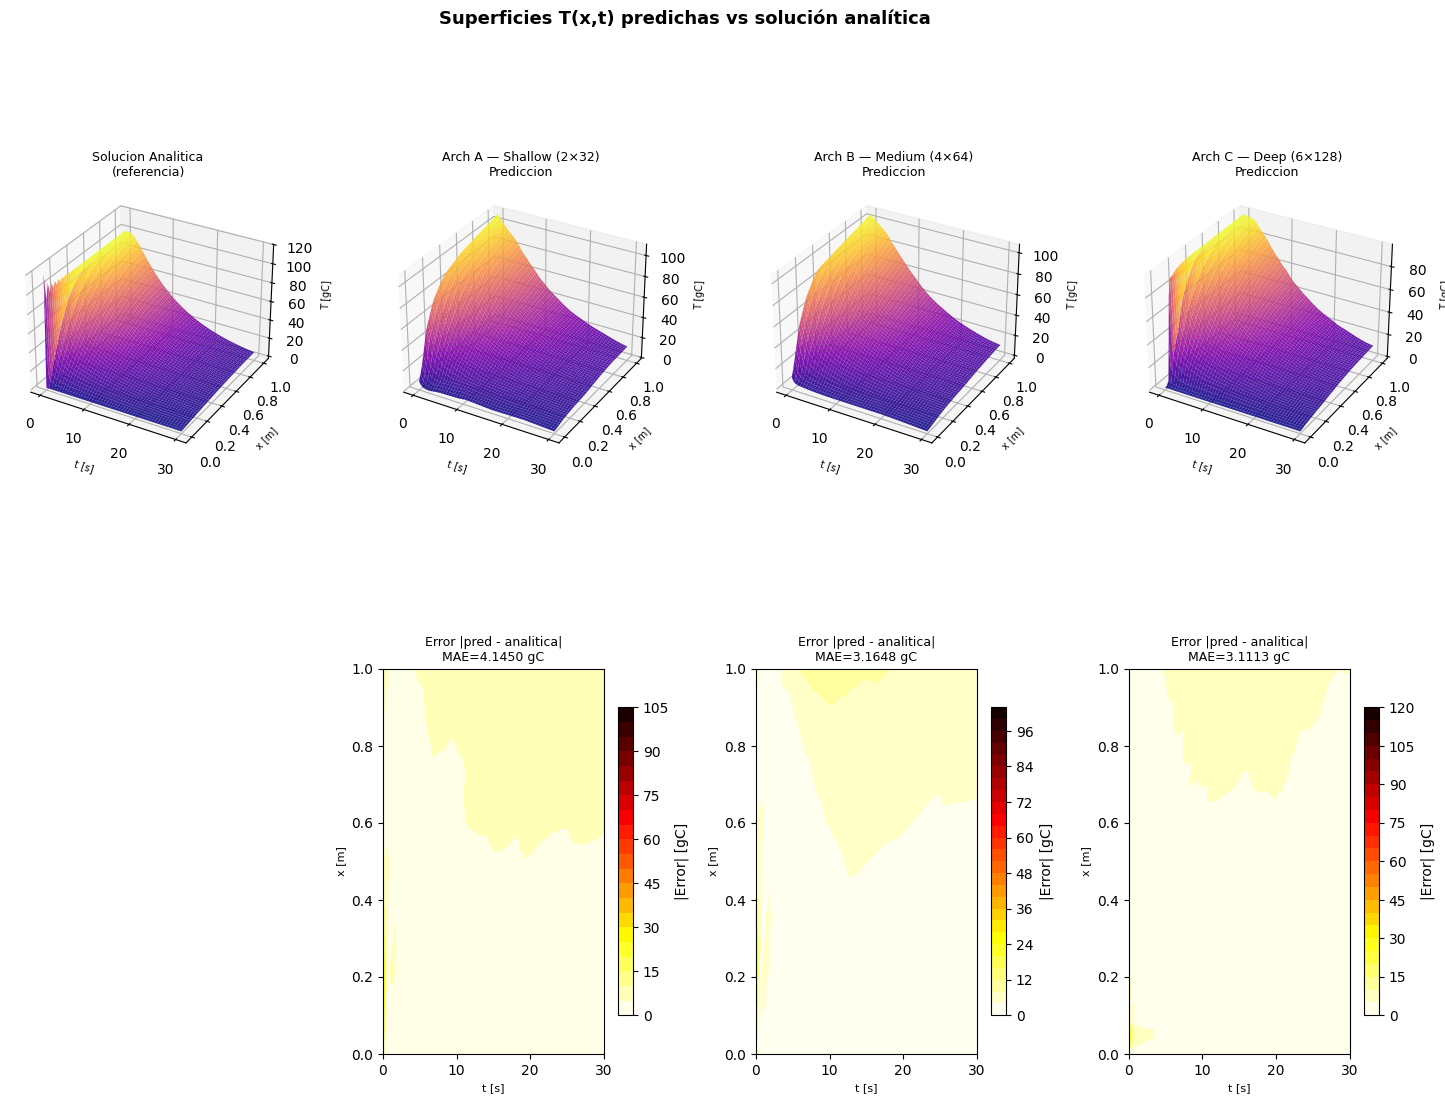

In [10]:
# ── Malla densa para prediccion ───────────────────────────────
t_fine = np.linspace(0, 30, 200)
x_fine = np.linspace(0, 1,  50)
TT, XX = np.meshgrid(t_fine, x_fine)

t_flat = TT.ravel().astype(np.float32)
x_flat = XX.ravel().astype(np.float32)
grid   = np.column_stack([t_flat, x_flat])
grid_s = scaler_X.transform(grid).astype(np.float32)

# ── Solucion analitica (referencia) ──────────────────────────
def T_analitica(x, t, n_terms=50):
    T = np.zeros_like(x, dtype=float)
    for n in range(n_terms):
        k = (2*n + 1) * np.pi / (2*L)
        T += (1/(2*n+1)) * np.sin(k*x) * np.exp(-alpha**2 * k**2 * t)
    return (400/np.pi) * T

T_ref = T_analitica(x_flat, t_flat).reshape(TT.shape)

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig,
                        hspace=0.4, wspace=0.35)

# Referencia analitica
ax_ref = fig.add_subplot(gs[0, 0], projection='3d')
ax_ref.plot_surface(TT, XX, T_ref, cmap=cm.plasma,
                    alpha=0.9, linewidth=0)
ax_ref.set_title('Solucion Analitica\n(referencia)', fontsize=9)
ax_ref.set_xlabel('t [s]', fontsize=7)
ax_ref.set_ylabel('x [m]', fontsize=7)
ax_ref.set_zlabel('T [gC]', fontsize=7)

# Tres modelos y sus errores
for col_idx, (nombre, modelo) in enumerate(
        zip(resultados.keys(), [model_A, model_B, model_C])):

    pred_s = modelo.predict(grid_s, verbose=0)
    pred   = scaler_y.inverse_transform(pred_s).reshape(TT.shape)
    err    = np.abs(pred - T_ref)

    # Superficie predicha
    ax_s = fig.add_subplot(gs[0, col_idx+1], projection='3d')
    ax_s.plot_surface(TT, XX, pred, cmap=cm.plasma,
                      alpha=0.9, linewidth=0)
    ax_s.set_title(f'{etiquetas[nombre]}\nPrediccion', fontsize=9)
    ax_s.set_xlabel('t [s]', fontsize=7)
    ax_s.set_ylabel('x [m]', fontsize=7)
    ax_s.set_zlabel('T [gC]', fontsize=7)

    # Mapa de error
    ax_e = fig.add_subplot(gs[1, col_idx+1])
    im   = ax_e.contourf(TT, XX, err, levels=25, cmap='hot_r')
    fig.colorbar(im, ax=ax_e, label='|Error| [gC]', shrink=0.8)
    ax_e.set_title(f'Error |pred - analitica|\nMAE={err.mean():.4f} gC',
                   fontsize=9)
    ax_e.set_xlabel('t [s]', fontsize=8)
    ax_e.set_ylabel('x [m]', fontsize=8)

# Ocultar el ax[1,0] (no se usa)
fig.add_subplot(gs[1, 0]).set_visible(False)

fig.suptitle('Superficies T(x,t) predichas vs solución analítica',
             fontsize=13, fontweight='bold')
plt.savefig('superficies_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 10 — Gráfica 5: Perfiles $T(x)$ en tiempos seleccionados

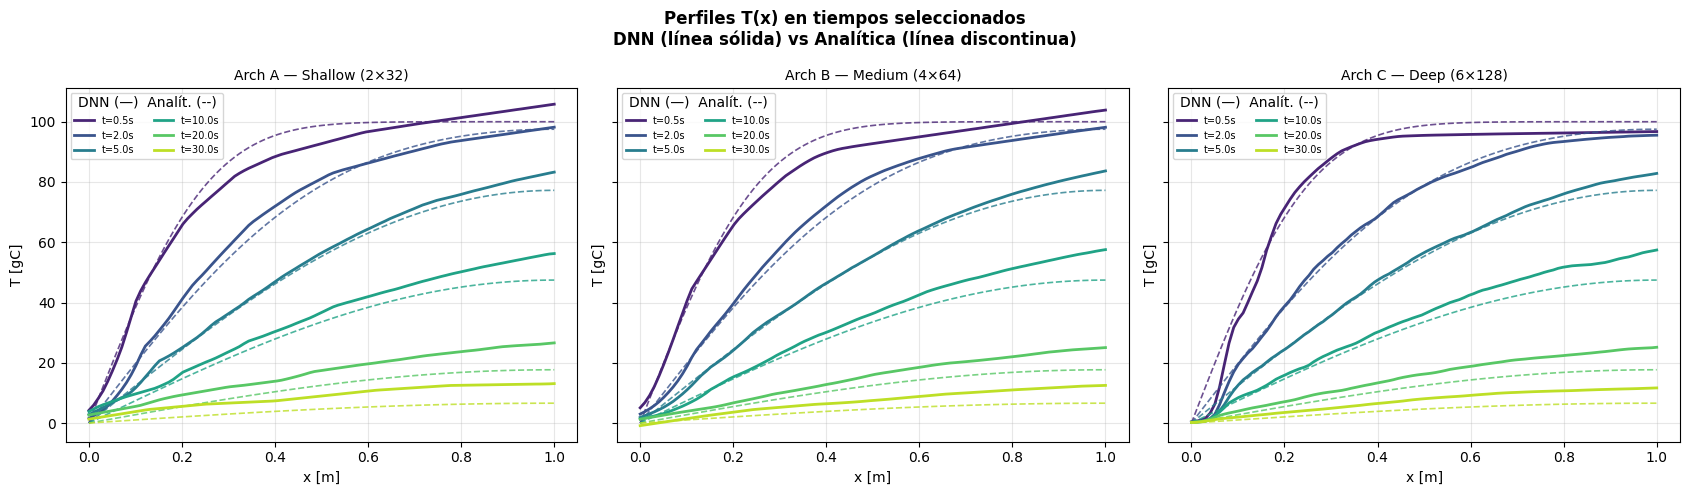

In [11]:
tiempos_eval = [0.5, 2.0, 5.0, 10.0, 20.0, 30.0]
x_eval       = np.linspace(0, L, 100).astype(np.float32)
colores_t    = plt.cm.viridis(np.linspace(0.1, 0.9, len(tiempos_eval)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (nombre, modelo) in zip(axes,
        zip(resultados.keys(), [model_A, model_B, model_C])):

    for t_ev, ctcolor in zip(tiempos_eval, colores_t):
        # Analitica
        T_an = T_analitica(x_eval, t_ev)
        ax.plot(x_eval, T_an, '--', color=ctcolor, lw=1.2, alpha=0.8)

        # Red neuronal
        inp = np.column_stack([
            np.full_like(x_eval, t_ev), x_eval])
        inp_s = scaler_X.transform(inp).astype(np.float32)
        pred_s = modelo.predict(inp_s, verbose=0)
        pred   = scaler_y.inverse_transform(pred_s).flatten()
        ax.plot(x_eval, pred, '-', color=ctcolor, lw=2,
                label=f't={t_ev:.1f}s')

    ax.set_xlabel('x [m]', fontsize=10)
    ax.set_ylabel('T [gC]', fontsize=10)
    ax.set_title(etiquetas[nombre], fontsize=10)
    ax.legend(fontsize=7, ncol=2, title='DNN (—)  Analít. (--)')
    ax.grid(True, alpha=0.3)

fig.suptitle('Perfiles T(x) en tiempos seleccionados\nDNN (línea sólida) vs Analítica (línea discontinua)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('perfiles_temp.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 11 — Gráfica 6: Evolución temporal en nodos seleccionados

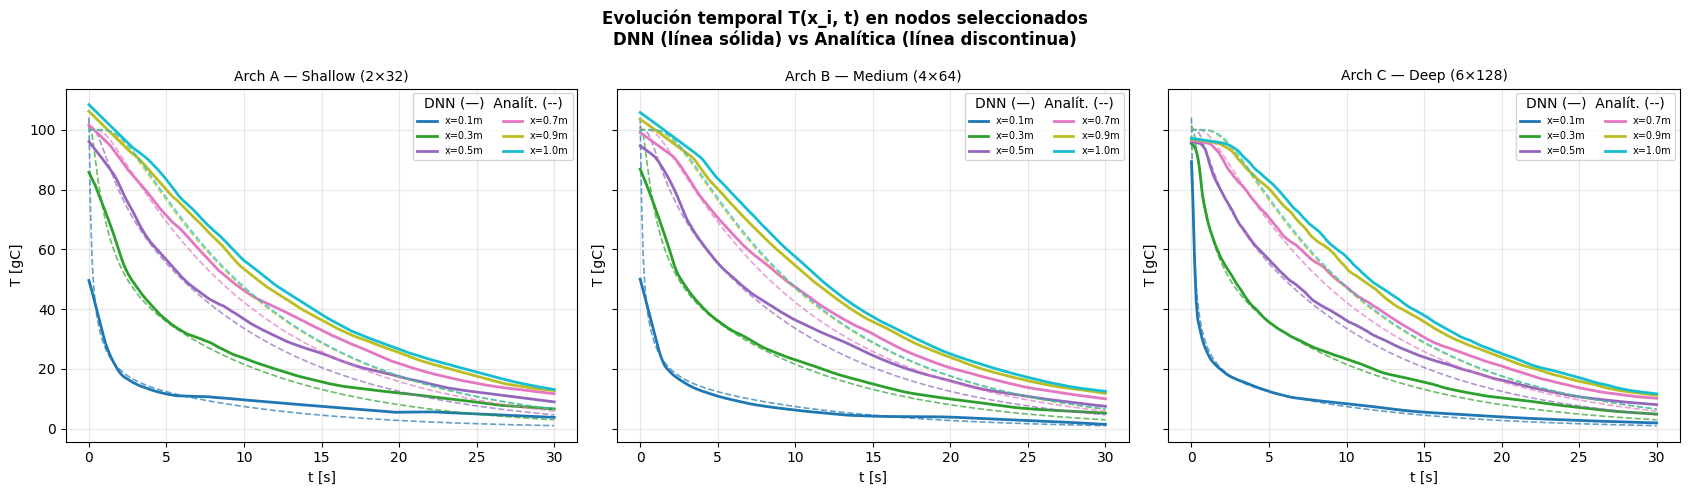

In [12]:
nodos_x  = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
t_eval   = np.linspace(0, 30, 300).astype(np.float32)
col_nodo = plt.cm.tab10(np.linspace(0, 1, len(nodos_x)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (nombre, modelo) in zip(axes,
        zip(resultados.keys(), [model_A, model_B, model_C])):

    for xi, cn in zip(nodos_x, col_nodo):
        # Analitica
        T_an = np.array([T_analitica(np.array([xi]), t)[0] for t in t_eval])
        ax.plot(t_eval, T_an, '--', color=cn, lw=1.2, alpha=0.7)

        # Red neuronal
        inp   = np.column_stack([t_eval, np.full_like(t_eval, xi)])
        inp_s = scaler_X.transform(inp).astype(np.float32)
        pred  = scaler_y.inverse_transform(
                    modelo.predict(inp_s, verbose=0)).flatten()
        ax.plot(t_eval, pred, '-', color=cn, lw=2,
                label=f'x={xi:.1f}m')

    ax.set_xlabel('t [s]',  fontsize=10)
    ax.set_ylabel('T [gC]', fontsize=10)
    ax.set_title(etiquetas[nombre], fontsize=10)
    ax.legend(fontsize=7, ncol=2, title='DNN (—)  Analít. (--)')
    ax.grid(True, alpha=0.3)

fig.suptitle('Evolución temporal T(x_i, t) en nodos seleccionados\nDNN (línea sólida) vs Analítica (línea discontinua)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 12 — Gráfica 7: Análisis de eficiencia (precisión vs costo)

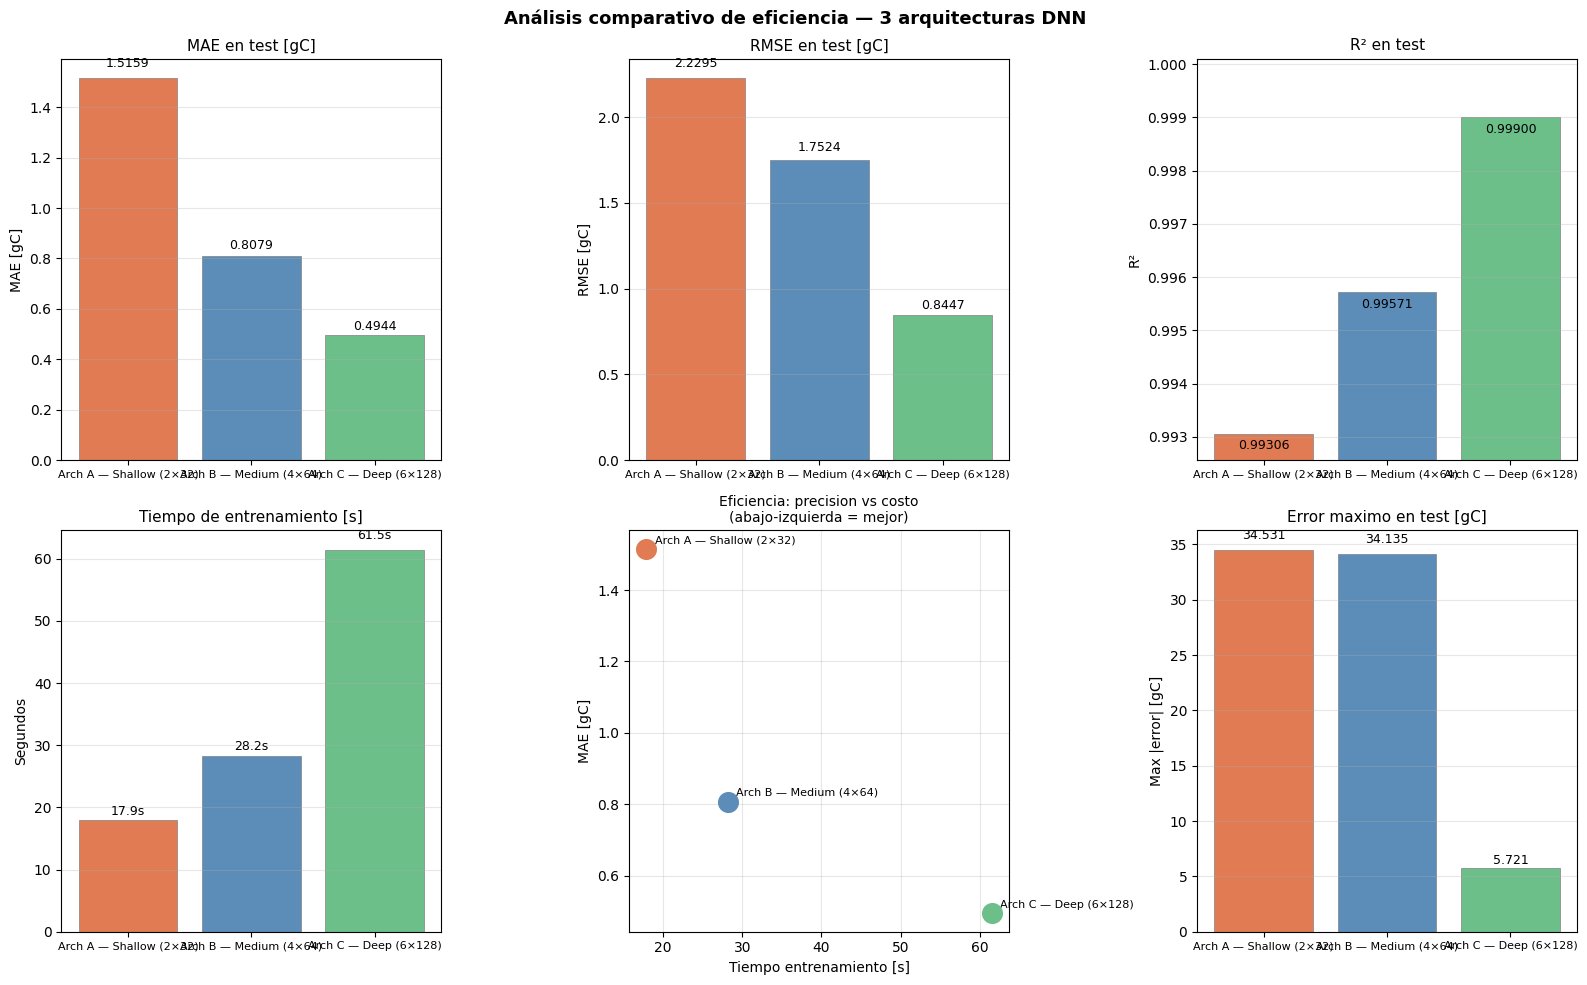

In [13]:
nombres   = list(resultados.keys())
maes      = [resultados[k]['MAE']          for k in nombres]
rmses     = [resultados[k]['RMSE']         for k in nombres]
r2s       = [resultados[k]['R2']           for k in nombres]
t_trains  = [resultados[k]['Tiempo_train'] for k in nombres]
params    = [resultados[k]['Params']       for k in nombres]
max_errs  = [resultados[k]['Max_Error']    for k in nombres]
cols_list = [colores[k] for k in nombres]
labs      = [etiquetas[k] for k in nombres]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── 1. MAE por modelo ─────────────────────────────────────────
bars = axes[0,0].bar(labs, maes, color=cols_list,
                     edgecolor='gray', linewidth=0.5)
for b, v in zip(bars, maes):
    axes[0,0].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0,0].set_title('MAE en test [gC]', fontsize=11)
axes[0,0].set_ylabel('MAE [gC]');  axes[0,0].grid(axis='y', alpha=0.3)
axes[0,0].tick_params(axis='x', labelsize=8)

# ── 2. RMSE por modelo ────────────────────────────────────────
bars = axes[0,1].bar(labs, rmses, color=cols_list,
                     edgecolor='gray', linewidth=0.5)
for b, v in zip(bars, rmses):
    axes[0,1].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0,1].set_title('RMSE en test [gC]', fontsize=11)
axes[0,1].set_ylabel('RMSE [gC]');  axes[0,1].grid(axis='y', alpha=0.3)
axes[0,1].tick_params(axis='x', labelsize=8)

# ── 3. R² por modelo ─────────────────────────────────────────
bars = axes[0,2].bar(labs, r2s, color=cols_list,
                     edgecolor='gray', linewidth=0.5)
for b, v in zip(bars, r2s):
    axes[0,2].text(b.get_x()+b.get_width()/2,
                   v - (1-min(r2s))*0.05,
                   f'{v:.5f}', ha='center', va='bottom', fontsize=9)
axes[0,2].set_title('R² en test', fontsize=11)
axes[0,2].set_ylabel('R²');  axes[0,2].grid(axis='y', alpha=0.3)
axes[0,2].set_ylim(min(r2s)*0.9995, 1.0001)
axes[0,2].tick_params(axis='x', labelsize=8)

# ── 4. Tiempo de entrenamiento ───────────────────────────────
bars = axes[1,0].bar(labs, t_trains, color=cols_list,
                     edgecolor='gray', linewidth=0.5)
for b, v in zip(bars, t_trains):
    axes[1,0].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.1f}s', ha='center', va='bottom', fontsize=9)
axes[1,0].set_title('Tiempo de entrenamiento [s]', fontsize=11)
axes[1,0].set_ylabel('Segundos');  axes[1,0].grid(axis='y', alpha=0.3)
axes[1,0].tick_params(axis='x', labelsize=8)

# ── 5. Eficiencia: MAE vs Tiempo (scatter) ───────────────────
for k, tt, mae, col, lab in zip(nombres, t_trains, maes, cols_list, labs):
    axes[1,1].scatter(tt, mae, color=col, s=200, zorder=5)
    axes[1,1].annotate(lab, (tt, mae),
                       textcoords='offset points',
                       xytext=(6, 4), fontsize=8)
axes[1,1].set_xlabel('Tiempo entrenamiento [s]', fontsize=10)
axes[1,1].set_ylabel('MAE [gC]', fontsize=10)
axes[1,1].set_title('Eficiencia: precision vs costo\n(abajo-izquierda = mejor)', fontsize=10)
axes[1,1].grid(True, alpha=0.3)

# ── 6. Error maximo por modelo ───────────────────────────────
bars = axes[1,2].bar(labs, max_errs, color=cols_list,
                     edgecolor='gray', linewidth=0.5)
for b, v in zip(bars, max_errs):
    axes[1,2].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.3f}', ha='center', va='bottom', fontsize=9)
axes[1,2].set_title('Error maximo en test [gC]', fontsize=11)
axes[1,2].set_ylabel('Max |error| [gC]');  axes[1,2].grid(axis='y', alpha=0.3)
axes[1,2].tick_params(axis='x', labelsize=8)

fig.suptitle('Análisis comparativo de eficiencia — 3 arquitecturas DNN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eficiencia_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 13 — Gráfica 8: Convergencia de la pérdida en escala lineal (detalle)

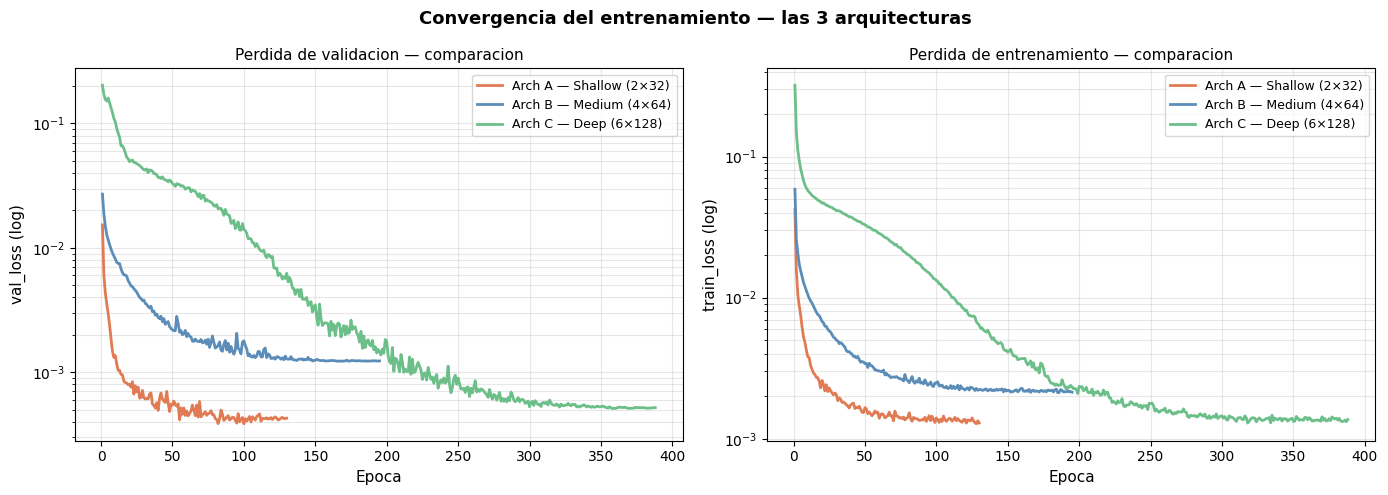

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel izquierdo: val_loss de los 3 modelos superpuesto ────
for nombre, hist in historiales.items():
    ep  = range(1, len(hist.history['val_loss']) + 1)
    axes[0].semilogy(ep, hist.history['val_loss'],
                     color=colores[nombre], lw=2,
                     label=etiquetas[nombre])
axes[0].set_xlabel('Epoca', fontsize=11)
axes[0].set_ylabel('val_loss (log)', fontsize=11)
axes[0].set_title('Perdida de validacion — comparacion', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, which='both', alpha=0.3)

# ── Panel derecho: train_loss de los 3 modelos superpuesto ────
for nombre, hist in historiales.items():
    ep  = range(1, len(hist.history['loss']) + 1)
    axes[1].semilogy(ep, hist.history['loss'],
                     color=colores[nombre], lw=2,
                     label=etiquetas[nombre])
axes[1].set_xlabel('Epoca', fontsize=11)
axes[1].set_ylabel('train_loss (log)', fontsize=11)
axes[1].set_title('Perdida de entrenamiento — comparacion', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, which='both', alpha=0.3)

fig.suptitle('Convergencia del entrenamiento — las 3 arquitecturas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('convergencia_comparada.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 14 — Resumen final y conclusión

In [15]:
# ── Tabla de ranking final ─────────────────────────────────────
df_final = pd.DataFrame({
    'Modelo'         : [etiquetas[k] for k in resultados],
    'Parametros'     : [resultados[k]['Params']        for k in resultados],
    'Epocas'         : [resultados[k]['Epocas']        for k in resultados],
    'MAE [gC]'       : [round(resultados[k]['MAE'],   5) for k in resultados],
    'RMSE [gC]'      : [round(resultados[k]['RMSE'],  5) for k in resultados],
    'R2'             : [round(resultados[k]['R2'],    6) for k in resultados],
    'MaxErr [gC]'    : [round(resultados[k]['Max_Error'],3) for k in resultados],
    'T_train [s]'    : [round(resultados[k]['Tiempo_train'],2) for k in resultados],
})

# Ranking por MAE
df_final = df_final.sort_values('MAE [gC]').reset_index(drop=True)
df_final.index = df_final.index + 1
df_final.index.name = 'Rank'

print('\n' + '='*75)
print('  RANKING FINAL — MENOR MAE = MEJOR MODELO')
print('='*75)
display(df_final)

# ── Conclusion ────────────────────────────────────────────────
mejor_mae  = df_final.loc[1, 'Modelo']
mejor_r2   = df_final.loc[df_final['R2'].idxmax(), 'Modelo']

print(f'\n  Mejor modelo por MAE   : {mejor_mae}')
print(f'  Mejor modelo por R2    : {mejor_r2}')
print()
print('  Archivos guardados:')
for f in ['perdida_arquitecturas.png', 'scatter_test.png',
           'histograma_error.png', 'superficies_prediccion.png',
           'perfiles_temp.png', 'evolucion_temporal.png',
           'eficiencia_comparativa.png', 'convergencia_comparada.png']:
    print(f'    {f}')


  RANKING FINAL — MENOR MAE = MEJOR MODELO


,Modelo,Parametros,Epocas,MAE [gC],RMSE [gC],R2,MaxErr [gC],T_train [s]
Rank,,,,,,,,
1,Arch C — Deep (6×128),49729,388,0.49441,0.84472,0.999004,5.721000,61.50
2,Arch B — Medium (4×64),12737,195,0.80787,1.75243,0.995712,34.134998,28.21
3,Arch A — Shallow (2×32),1185,130,1.51591,2.22945,0.993060,34.530998,17.92



  Mejor modelo por MAE   : Arch C — Deep (6×128)
  Mejor modelo por R2    : Arch C — Deep (6×128)

  Archivos guardados:
    perdida_arquitecturas.png
    scatter_test.png
    histograma_error.png
    superficies_prediccion.png
    perfiles_temp.png
    evolucion_temporal.png
    eficiencia_comparativa.png
    convergencia_comparada.png


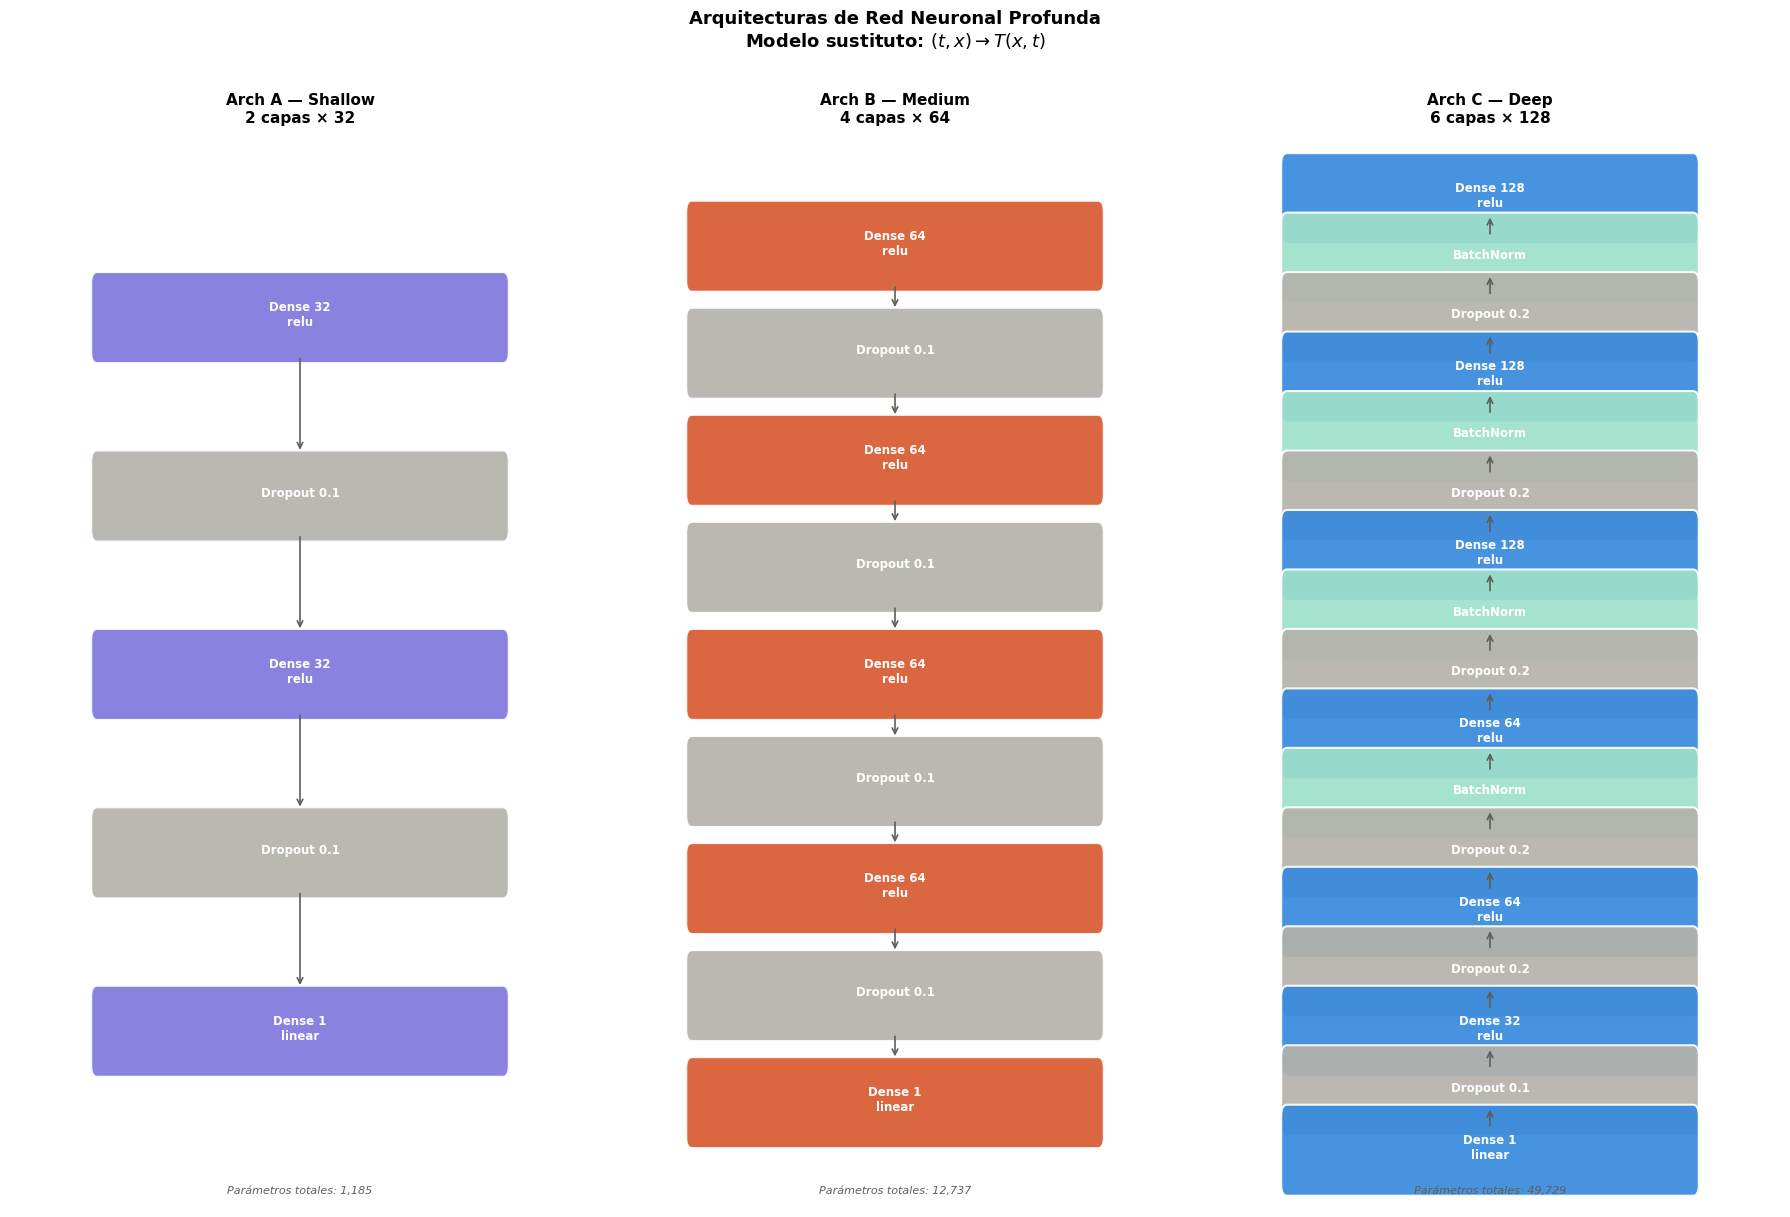

Guardado: arquitecturas_dnn.png


In [16]:
# ── Visualización de las 3 arquitecturas con keras.utils.plot_model ──────────
import keras
from IPython.display import display, Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Opción 1: plot_model de Keras (requiere graphviz instalado) ────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 12))

for ax, (nombre, modelo), color_capas in zip(
        axes,
        [('Arch A — Shallow\n2 capas × 32', model_A),
         ('Arch B — Medium\n4 capas × 64',  model_B),
         ('Arch C — Deep\n6 capas × 128',   model_C)],
        ['#7F77DD', '#D85A30', '#378ADD']):

    ax.axis('off')
    capas = [l for l in modelo.layers]
    n = len(capas)
    y_step = 1.0 / (n + 1)

    for idx, capa in enumerate(capas):
        y = 1.0 - (idx + 1) * y_step
        nombre_capa = capa.name
        cfg = capa.get_config()

        # Color por tipo de capa
        if 'input' in nombre_capa:
            color = '#888780'; texto = 'Input\n(t, x)'
        elif 'dense' in nombre_capa:
            units = cfg.get('units', '?')
            act   = cfg.get('activation', '')
            color = color_capas
            texto = f'Dense {units}\n{act}'
        elif 'dropout' in nombre_capa:
            rate  = cfg.get('rate', '?')
            color = '#B4B2A9'; texto = f'Dropout {rate}'
        elif 'batch_norm' in nombre_capa:
            color = '#9FE1CB'; texto = 'BatchNorm'
        else:
            color = '#D3D1C7'; texto = nombre_capa

        # Caja de la capa
        rect = mpatches.FancyBboxPatch(
            (0.15, y - 0.035), 0.70, 0.065,
            boxstyle='round,pad=0.01',
            facecolor=color, edgecolor='white',
            linewidth=1.5, alpha=0.92,
            transform=ax.transAxes, clip_on=False)
        ax.add_patch(rect)

        ax.text(0.50, y, texto,
                ha='center', va='center',
                fontsize=8.5, color='white', fontweight='bold',
                transform=ax.transAxes)

        # Flecha al siguiente bloque
        if idx < n - 1:
            y_next = 1.0 - (idx + 2) * y_step
            ax.annotate('', xy=(0.50, y_next + 0.038),
                        xytext=(0.50, y - 0.038),
                        xycoords='axes fraction',
                        textcoords='axes fraction',
                        arrowprops=dict(arrowstyle='->', color='#5F5E5A',
                                        lw=1.2))

    # Conteo de parámetros
    ax.text(0.5, 0.01,
            f'Parámetros totales: {modelo.count_params():,}',
            ha='center', va='bottom', fontsize=8,
            color='#5F5E5A', transform=ax.transAxes,
            style='italic')
    ax.set_title(nombre, fontsize=11, fontweight='bold', pad=10)

plt.suptitle('Arquitecturas de Red Neuronal Profunda\nModelo sustituto: $(t, x) \\rightarrow T(x,t)$',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('arquitecturas_dnn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: arquitecturas_dnn.png")